In [1]:
# --- Standard library ---
import sys
import os
from os.path import join
import time

# --- Third-party scientific stack ---
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Machine learning / statistics ---
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE, SpectralEmbedding
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from sklearn.metrics import pairwise
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import AffinityPropagation

# --- SciPy ---
from scipy.linalg import LinAlgError, qr, svd
from scipy.sparse import csgraph

# --- Utilities ---
from tqdm import tqdm
import joblib
from joblib import parallel_backend
import numexpr as ne

# --- Local / custom modules ---
import fpsample



# Self-written libraries
sys.path.append(join(os.getcwd(), "library"))
import SPC

# Loading

In [2]:
# File path
# Input your own file path here
file_path = r"C:\used\data\Clustering_Analysis\Clustering_Analysis\Correlation_Map.bin"

# Use memory mapping to read the large matrix
fragment = np.memmap(
    file_path,
    dtype=np.float64,   # Explicitly specify data type
    mode="r",           # Read-only mode
    shape=(28800, 28800)
)

# Time index
t_index = np.arange(fragment.shape[0])
idx=np.arange(fragment.shape[0])

In [3]:
# --- Labels Loading ---
results = pd.read_csv(
    r'D:\used\Log_Data_Coherent_Correlation_Imaging.txt',
    sep="\t"
)

# Rename columns properly (removed trailing empty column name)
results.columns = [
    'Timestamp', 'Helicity', 'State', 'Mode',
    'Topography_Nr', 'Translation_y', 'Translation_x', 'FileName',''
]

# Select the row of interest (example: idx+1)
mode_value = results.loc[idx + 1, 'Mode']
state_value = results.loc[idx + 1, 'State']

# Find indices corresponding to "Not assigned"
filter_index = np.where(mode_value == ' Not assigned')
print("Indices with 'Not assigned':", filter_index)

Indices with 'Not assigned': (array([  614,   615,   632,   633,   637,  1738,  1739,  1740,  2007,
        2678,  2694,  2695,  2696,  2719,  2720,  2722,  2734,  2735,
        2815,  2824,  2835,  2839,  2843,  2854,  2863,  2865,  2867,
        2874,  2944,  2969,  2976,  2983,  3011,  3012,  3030,  3047,
        3048,  3049,  3050,  3054,  3055,  3072,  3183,  3198,  3839,
        3847,  3853,  3854,  3954,  3988,  4040,  4520,  4745,  4790,
        4796,  4994,  5120,  5129,  5363,  5364,  5477,  5572, 11508,
       11597, 11598, 11599, 11839, 11858, 11874, 16375, 16386, 16476,
       16477, 16478, 16479, 18729, 18730, 18731, 18732, 18734, 18735,
       18737, 18739, 18964, 18983, 18984, 18986, 19005, 19045, 19047,
       19107, 19169, 19220, 19221, 19301, 19311, 19630, 19658, 19743,
       19746, 19751, 19758, 19872, 19922, 19957, 19966, 19967, 19990,
       19991, 20047, 20062, 20069, 20072, 20073, 20074, 20085, 20086,
       20098, 20200, 20201, 20202, 20203, 20475, 20519, 2053

In [4]:
# Convert mode label to integer 
modes_encoded, unique_items = pd.factorize(mode_value)

print("Conversion mapping:")
for idx, item in enumerate(unique_items):
    print(f"Original label: {item}  →  Encoded: {idx}")

# Convert to numpy arrays
modes = modes_encoded.astype(float)
states = state_value.to_numpy().astype(float)

# Replace "Not assigned" entries with NaN
modes[filter_index]=np.nan
states[filter_index]=np.nan


Conversion mapping:
Original label:  1-1  →  Encoded: 0
Original label:  1-2  →  Encoded: 1
Original label:  1-4  →  Encoded: 2
Original label:  Not assigned  →  Encoded: 3
Original label:  2-5  →  Encoded: 4
Original label:  2-1  →  Encoded: 5
Original label:  3-1  →  Encoded: 6
Original label:  4-1  →  Encoded: 7
Original label:  5-5  →  Encoded: 8
Original label:  6-1  →  Encoded: 9
Original label:  7-1  →  Encoded: 10
Original label:  7-2  →  Encoded: 11
Original label:  2-8  →  Encoded: 12
Original label:  2-9  →  Encoded: 13
Original label:  2-3  →  Encoded: 14
Original label:  2-4  →  Encoded: 15
Original label:  2-7  →  Encoded: 16
Original label:  8-1  →  Encoded: 17
Original label:  9-1  →  Encoded: 18
Original label:  10-1  →  Encoded: 19
Original label:  11-1  →  Encoded: 20
Original label:  12-1  →  Encoded: 21
Original label:  13-1  →  Encoded: 22
Original label:  14-3  →  Encoded: 23
Original label:  14-1  →  Encoded: 24
Original label:  14-2  →  Encoded: 25
Original lab

In [5]:
# --- Relabel function ---
def relabel(labels):
    """
    Relabels an array of labels:
    1. Replace each unique label with the median index of its occurrences.
    2. Reassign labels to consecutive integers starting from 0.
    NaN values are preserved.
    """
    labels = np.array(labels, dtype=float)

    # Get unique non-NaN items
    unique_items = np.unique(labels[~np.isnan(labels)])
    print("Unique items before relabeling:", unique_items)

    # Step 1: Replace each label with the median index of its occurrences
    for item in unique_items:
        indices = np.where(labels == item)[0]
        median_index = indices[len(indices) // 2]  # middle occurrence
        labels[indices] = median_index
        print("item: %s, old value: %s" % (item, median_index))

    # Step 2: Normalize labels to consecutive integers
    unique_items = np.sort(np.unique(labels[~np.isnan(labels)]))
    for new_label, old_value in enumerate(unique_items):
        labels[labels == old_value] = new_label
        print("old value: %s, new label: %s" % (old_value, new_label))


    return labels

# Apply relabeling
modes = relabel(modes)
states = relabel(states)

Unique items before relabeling: [ 0.  1.  2.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.]
item: 0.0, old value: 580
item: 1.0, old value: 19029
item: 2.0, old value: 3851
item: 4.0, old value: 1816
item: 5.0, old value: 2745
item: 6.0, old value: 21509
item: 7.0, old value: 5388
item: 8.0, old value: 16220
item: 9.0, old value: 25024
item: 10.0, old value: 10034
item: 11.0, old value: 10126
item: 12.0, old value: 2879
item: 13.0, old value: 23514
item: 14.0, old value: 5335
item: 15.0, old value: 21467
item: 16.0, old value: 2470
item: 17.0, old value: 2782
item: 18.0, old value: 3765
item: 19.0, old value: 2830
item: 20.0, old value: 2921
item: 21.0, old value: 3036
item: 22.0, old value: 19040
item: 23.0, old value: 4332
item: 24.0, old value: 3353
item

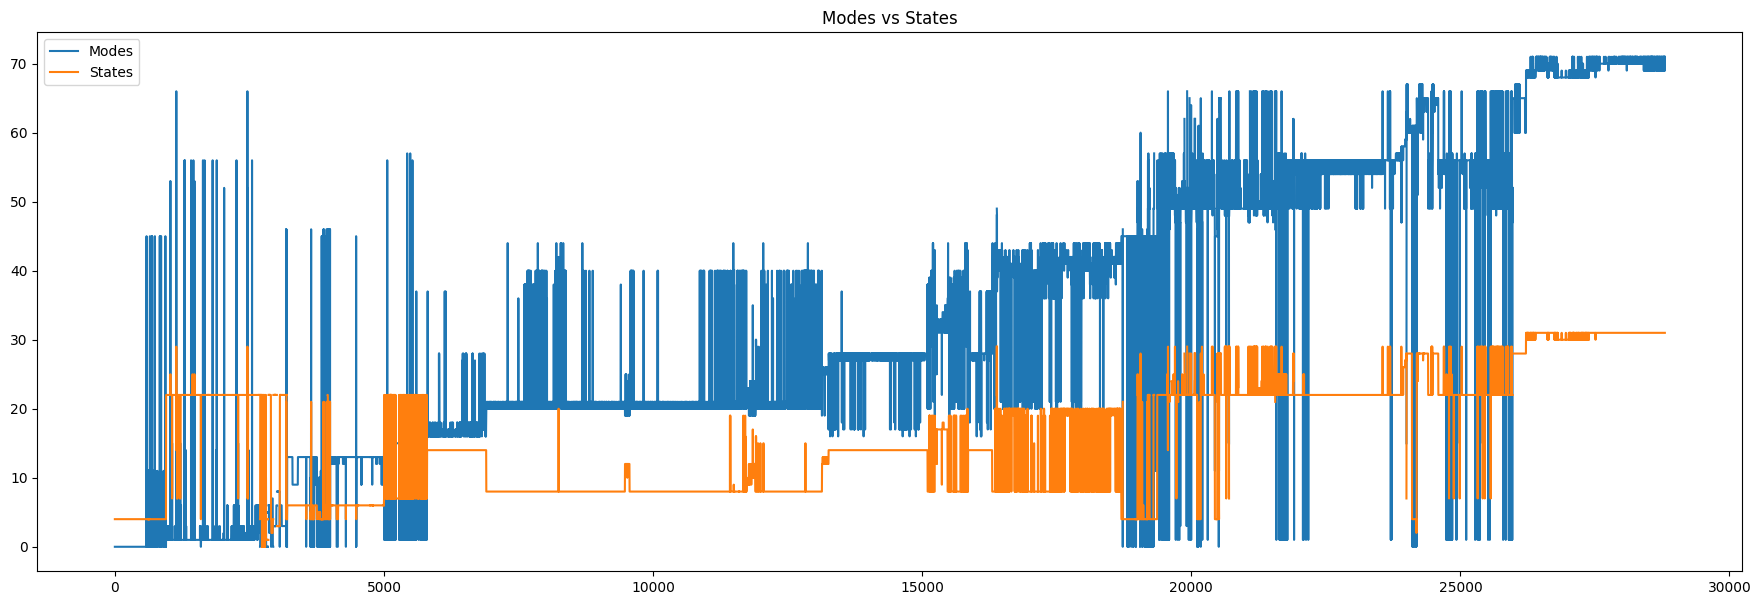

In [6]:
plt.figure(figsize=(22, 7))
plt.plot(modes,label='Modes')
plt.plot(states,label='States')
plt.legend()
plt.title("Modes vs States")
plt.show()

# Clustering process

In [7]:
# ============================================
# Iterative Spectral Clustering Workflow
# ============================================

# Initialize cluster dictionary
cluster_dict = {
    "Cluster_Nr": 0,                                # Cluster index number
    "Cluster_Frames": np.arange(fragment.shape[0]), # All frames initially belong to cluster 0
    "Nr_Frames": 0,                                 # Number of frames in cluster (updated later)
    "Threshold": 0,                                 # Reclustering threshold (updated later)
    "Order": 0,                                     # Order of correlation
    "Metric": 0,                                    # Similarity metric used ("correlation" or "cosine")
    "eigenvalues": np.arange(fragment.shape[0]),    # Placeholder for eigenvalues
}

# Store clusters in a list
cluster = [cluster_dict]

# Clustering parameters
first_threshold = 0.05   # Threshold for first cluster, ranges between 0 and 1, with smaller values imposing stricter criteria.
rc_threshold = 0.35      # The reclustering threshold for subclusters ranges between 0 and 1, with smaller values imposing stricter criteria.
force_iterations = 3     # Force splitting of clusters for how many iterations
order = 1                # Subcluster reclustering correlation order (0, 1, or 2): A larger order increases the separation of data points in the feature space, thereby enhancing the differences between categories.
                         # However, using too high an order is not recommended, as it can distort the distribution of neighboring points — causing the data in feature space to collapse toward a nearly curve arrangement.
metric = "correlation"   # Similarity metric ("correlation" or "cosine")

# Reset loop variables
cluster_idx = 0
stop = False

# Close all previous plots
plt.close("all")

# ============================================
# Iterative loop over clusters
# ============================================
while not stop:
    print("")
    print(f"=========== Clustering of Cluster Index: {cluster_idx} ===========")

    # Only process clusters with sufficient frames
    if len(cluster[cluster_idx]["Cluster_Frames"]) > 30:

        # --- Sampling ---
        if cluster_idx == 0:
            # First cluster: sample directly from full fragment space
            Sampler_1 = SPC.Sampler(
                cluster[cluster_idx]["Cluster_Frames"],
                feature_space=fragment,
                max_samples=500,
                min_samples=500
            )
            train_idx, test_idx, train_SN, test_SN = Sampler_1.shuffle(
                proportion=0.5, method="random"
            )
            print("Cluster size:", len(cluster[cluster_idx]["Cluster_Frames"]),
                    "Train size:", len(train_idx),
                    "Test size:", len(test_idx))

            # Build correlation maps  ！！！Here the parameter number in SPC.reconstruct_correlation_map reference to Correlation order of first cluster, now is 0.
            train_corr = SPC.reconstruct_correlation_map(
                train_idx, train_idx, fragment, 0, metric
            )
            test_corr = SPC.reconstruct_correlation_map(
                test_idx, train_idx, fragment, 0, metric
            ) if len(test_idx) != 0 else None

            threshold = first_threshold

        else:
            # Subsequent clusters: sample from sub-fragment space
            Sampler_2 = SPC.Sampler(
                cluster[cluster_idx]["Cluster_Frames"],
                feature_space=fragment[np.ix_(
                    cluster[cluster_idx]["Cluster_Frames"],
                    cluster[cluster_idx]["Cluster_Frames"]
                )],
                max_samples=500,
                min_samples=50
            )
            train_idx, test_idx, train_SN, test_SN = Sampler_2.shuffle(
                proportion=0.2, method="random"
            )
            print("Cluster size:", len(cluster[cluster_idx]["Cluster_Frames"]),
                    "Train size:", len(train_idx),
                    "Test size:", len(test_idx))

            # Build correlation maps
            train_corr = SPC.reconstruct_correlation_map(
                train_idx, train_idx, fragment, order, metric
            )
            test_corr = SPC.reconstruct_correlation_map(
                test_idx, train_idx, fragment, order, metric
            ) if len(test_idx) != 0 else None

            threshold = rc_threshold

        # --- Store cluster parameters ---
        cluster[cluster_idx]["Nr_Frames"] = len(train_idx) + len(test_idx)
        cluster[cluster_idx]["Order"] = order
        cluster[cluster_idx]["Metric"] = metric
        cluster[cluster_idx]["Threshold"] = threshold

        # --- Spectral Embedding ---
        print("Calculating Clustering")
        try:
            eigenvalues, eigenvectors, Laplacian_mat, train_affinity_mat = SPC.Spectral_embeding(
                train_corr, sigma_nn=2
            )
            norm_affinity_mat=train_affinity_mat/np.expand_dims(np.sum(train_affinity_mat,axis=-1),axis=-1)


            # Save eigen info
            cluster[cluster_idx]["eigenvalues"] = eigenvalues
            cluster[cluster_idx]["eigenvectors"] = eigenvectors
            cluster[cluster_idx]["eigenvec_shape"] = np.shape(eigenvectors)

            print(f"Smallest Eigenvalue = {eigenvalues[1]:.4f}")

            # --- Reclustering condition ---
            print("Recluster")
            if eigenvalues[1] < threshold:
                start_time = time.time()

                if cluster_idx == 0:
                    # For first cluster: number of clusters = count of eigenvalues below threshold
                    nr_cluster = np.sum(eigenvalues < threshold)
                else:
                    # For subclusters: use multiple criteria
                    nr_max_cluster = np.sum(eigenvalues < threshold)
                    nr_min_cluster = np.sum(eigenvalues < threshold / 10)
                    nr_gap_cluster = SPC.eigerngap(eigenvalues[:nr_max_cluster + 1])

                    #Choose cluster number based on gap/min criteria
                    #nr_cluster = np.max([nr_gap_cluster, nr_min_cluster]) # If iteration process is too slow, use this one
                    nr_cluster = 2

                    print(f"nr_max_cluster {nr_max_cluster}! Recluster number {nr_cluster}!")

                print(f"Reclustering condition satisfied "
                      f"(Eigenvalue = {eigenvalues[nr_cluster - 1]:.4f})! "
                      f"Recluster number {nr_cluster}")

                # --- Train clustering ---
                cluster_space, train_labels, model = SPC.clustering(
                    eigenvectors,
                    n_components=nr_cluster,
                    n_clusters=nr_cluster,
                    assign_labels="kmeans"
                )

                # --- Test clustering ---
                if len(test_idx) != 0:
                    test_norm_affinity = SPC.local_scaled_affinity(test_corr, train_corr, k=2)
                    # Normalize affinity matrix
                    test_norm_affinity=test_norm_affinity/np.expand_dims(np.sum(test_norm_affinity,axis=-1),axis=-1)
                    test_embed = np.dot(
                        test_norm_affinity @ norm_affinity_mat,
                        eigenvectors[:, :nr_cluster] / (1 - eigenvalues[:nr_cluster])
                    )
                    test_labels = model.predict(test_embed)
                else:
                    test_labels = []

                # --- Merge train/test labels ---
                labels = np.zeros(len(train_labels) + len(test_labels))
                labels[train_SN] = train_labels
                labels[test_SN] = test_labels

                # Timing
                end_time = time.time()
                print(f"Time for embedding: {end_time - start_time:.2f} seconds")

                # --- Process sub-clusters ---
                cluster = SPC.process_cluster(
                    model, cluster, cluster_idx, labels,
                    save=True
                )

            else:
                print(f"Cluster {cluster_idx} does not satisfy reclustering "
                      f"(smallest eigenvalue: {eigenvalues[1]:.4f})!\n")

        except Exception as e:
            print(f"Cluster {cluster_idx} failed due to error: {e}\n")

    else:
        print("Small cluster size: Skipping!")

    # --- Update index ---
    cluster_idx += 1
    if cluster_idx >= len(cluster):
        stop = True

# Final feedback
print("Iterative clustering algorithm finished!")

# Remove empty clusters
cluster = list(filter(None, cluster))

print(f"You determined {len(cluster)} clusters! (Threshold {threshold:.2f})")



=========== Clustering of Cluster Index: 0 ===========
Cluster size: 28800 Train size: 500 Test size: 28300
Calculating Clustering
Smallest Eigenvalue = 0.0000
Recluster
Reclustering condition satisfied (Eigenvalue = 0.0014)! Recluster number 7
Time for embedding: 0.90 seconds
Creating sub-cluster: 0-0.0
Saving subcluster 0-0.0 as new cluster 1.0
Creating sub-cluster: 0-1.0
Saving subcluster 0-1.0 as new cluster 2.0
Creating sub-cluster: 0-2.0
Saving subcluster 0-2.0 as new cluster 3.0
Creating sub-cluster: 0-3.0
Saving subcluster 0-3.0 as new cluster 4.0
Creating sub-cluster: 0-4.0
Saving subcluster 0-4.0 as new cluster 5.0
Creating sub-cluster: 0-5.0
Saving subcluster 0-5.0 as new cluster 6.0
Creating sub-cluster: 0-6.0
Saving subcluster 0-6.0 as new cluster 7.0

=========== Clustering of Cluster Index: 1 ===========
Cluster size: 8785 Train size: 500 Test size: 8285
Calculating Clustering
Smallest Eigenvalue = 0.0407
Recluster
nr_max_cluster 9! Recluster number 2!
Reclustering cond

# Reorder and Save

In [8]:
# Print number of clusters
print(f"Number of clusters: {len(cluster)}")

# Initialize labels with -1
my_labels = np.full(fragment.shape[0], -1, dtype=float)

# Assign cluster indices to frames
for i, c in enumerate(cluster):
    my_labels[c['Cluster_Frames']] = i

# Mask out filtered indices
my_labels[filter_index] = np.nan

# Relabel 
labels = relabel(my_labels)


Number of clusters: 30
Unique items before relabeling: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 14. 15. 17. 18. 19.
 20. 21. 22. 23. 24. 25. 26. 27. 28. 29.]
item: 0.0, old value: 4263
item: 1.0, old value: 22565
item: 2.0, old value: 20061
item: 3.0, old value: 15389
item: 4.0, old value: 27889
item: 5.0, old value: 26961
item: 6.0, old value: 24214
item: 7.0, old value: 24540
item: 8.0, old value: 3036
item: 9.0, old value: 11030
item: 10.0, old value: 17648
item: 11.0, old value: 14309
item: 12.0, old value: 6275
item: 14.0, old value: 3018
item: 15.0, old value: 11770
item: 17.0, old value: 2689
item: 18.0, old value: 5447
item: 19.0, old value: 21556
item: 20.0, old value: 2782
item: 21.0, old value: 2830
item: 22.0, old value: 18994
item: 23.0, old value: 3759
item: 24.0, old value: 624
item: 25.0, old value: 18853
item: 26.0, old value: 11871
item: 27.0, old value: 15335
item: 28.0, old value: 2142
item: 29.0, old value: 3128
old value: 624.0, new label: 0
old value:

In [16]:
# Save clustering result

# Wrap into an xarray DataArray with dimension labels
data = xr.DataArray(
    labels,
    dims=("label"),
    coords={"label": np.arange(np.shape(labels)[0])},
    name="my_label"
)


# Save to NetCDF (common scientific format)
fname="Clustering_result.nc"
if os.path.exists(fname):
    os.remove(fname)
data.to_netcdf(fname)

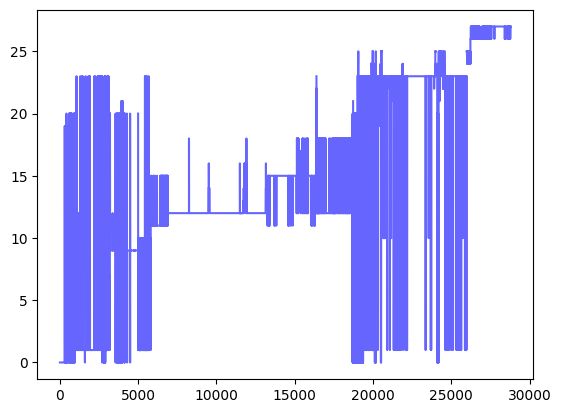

In [9]:
plt.plot(labels, label='My label', alpha=0.6, color='blue')
plt.show()

# Analyse Result

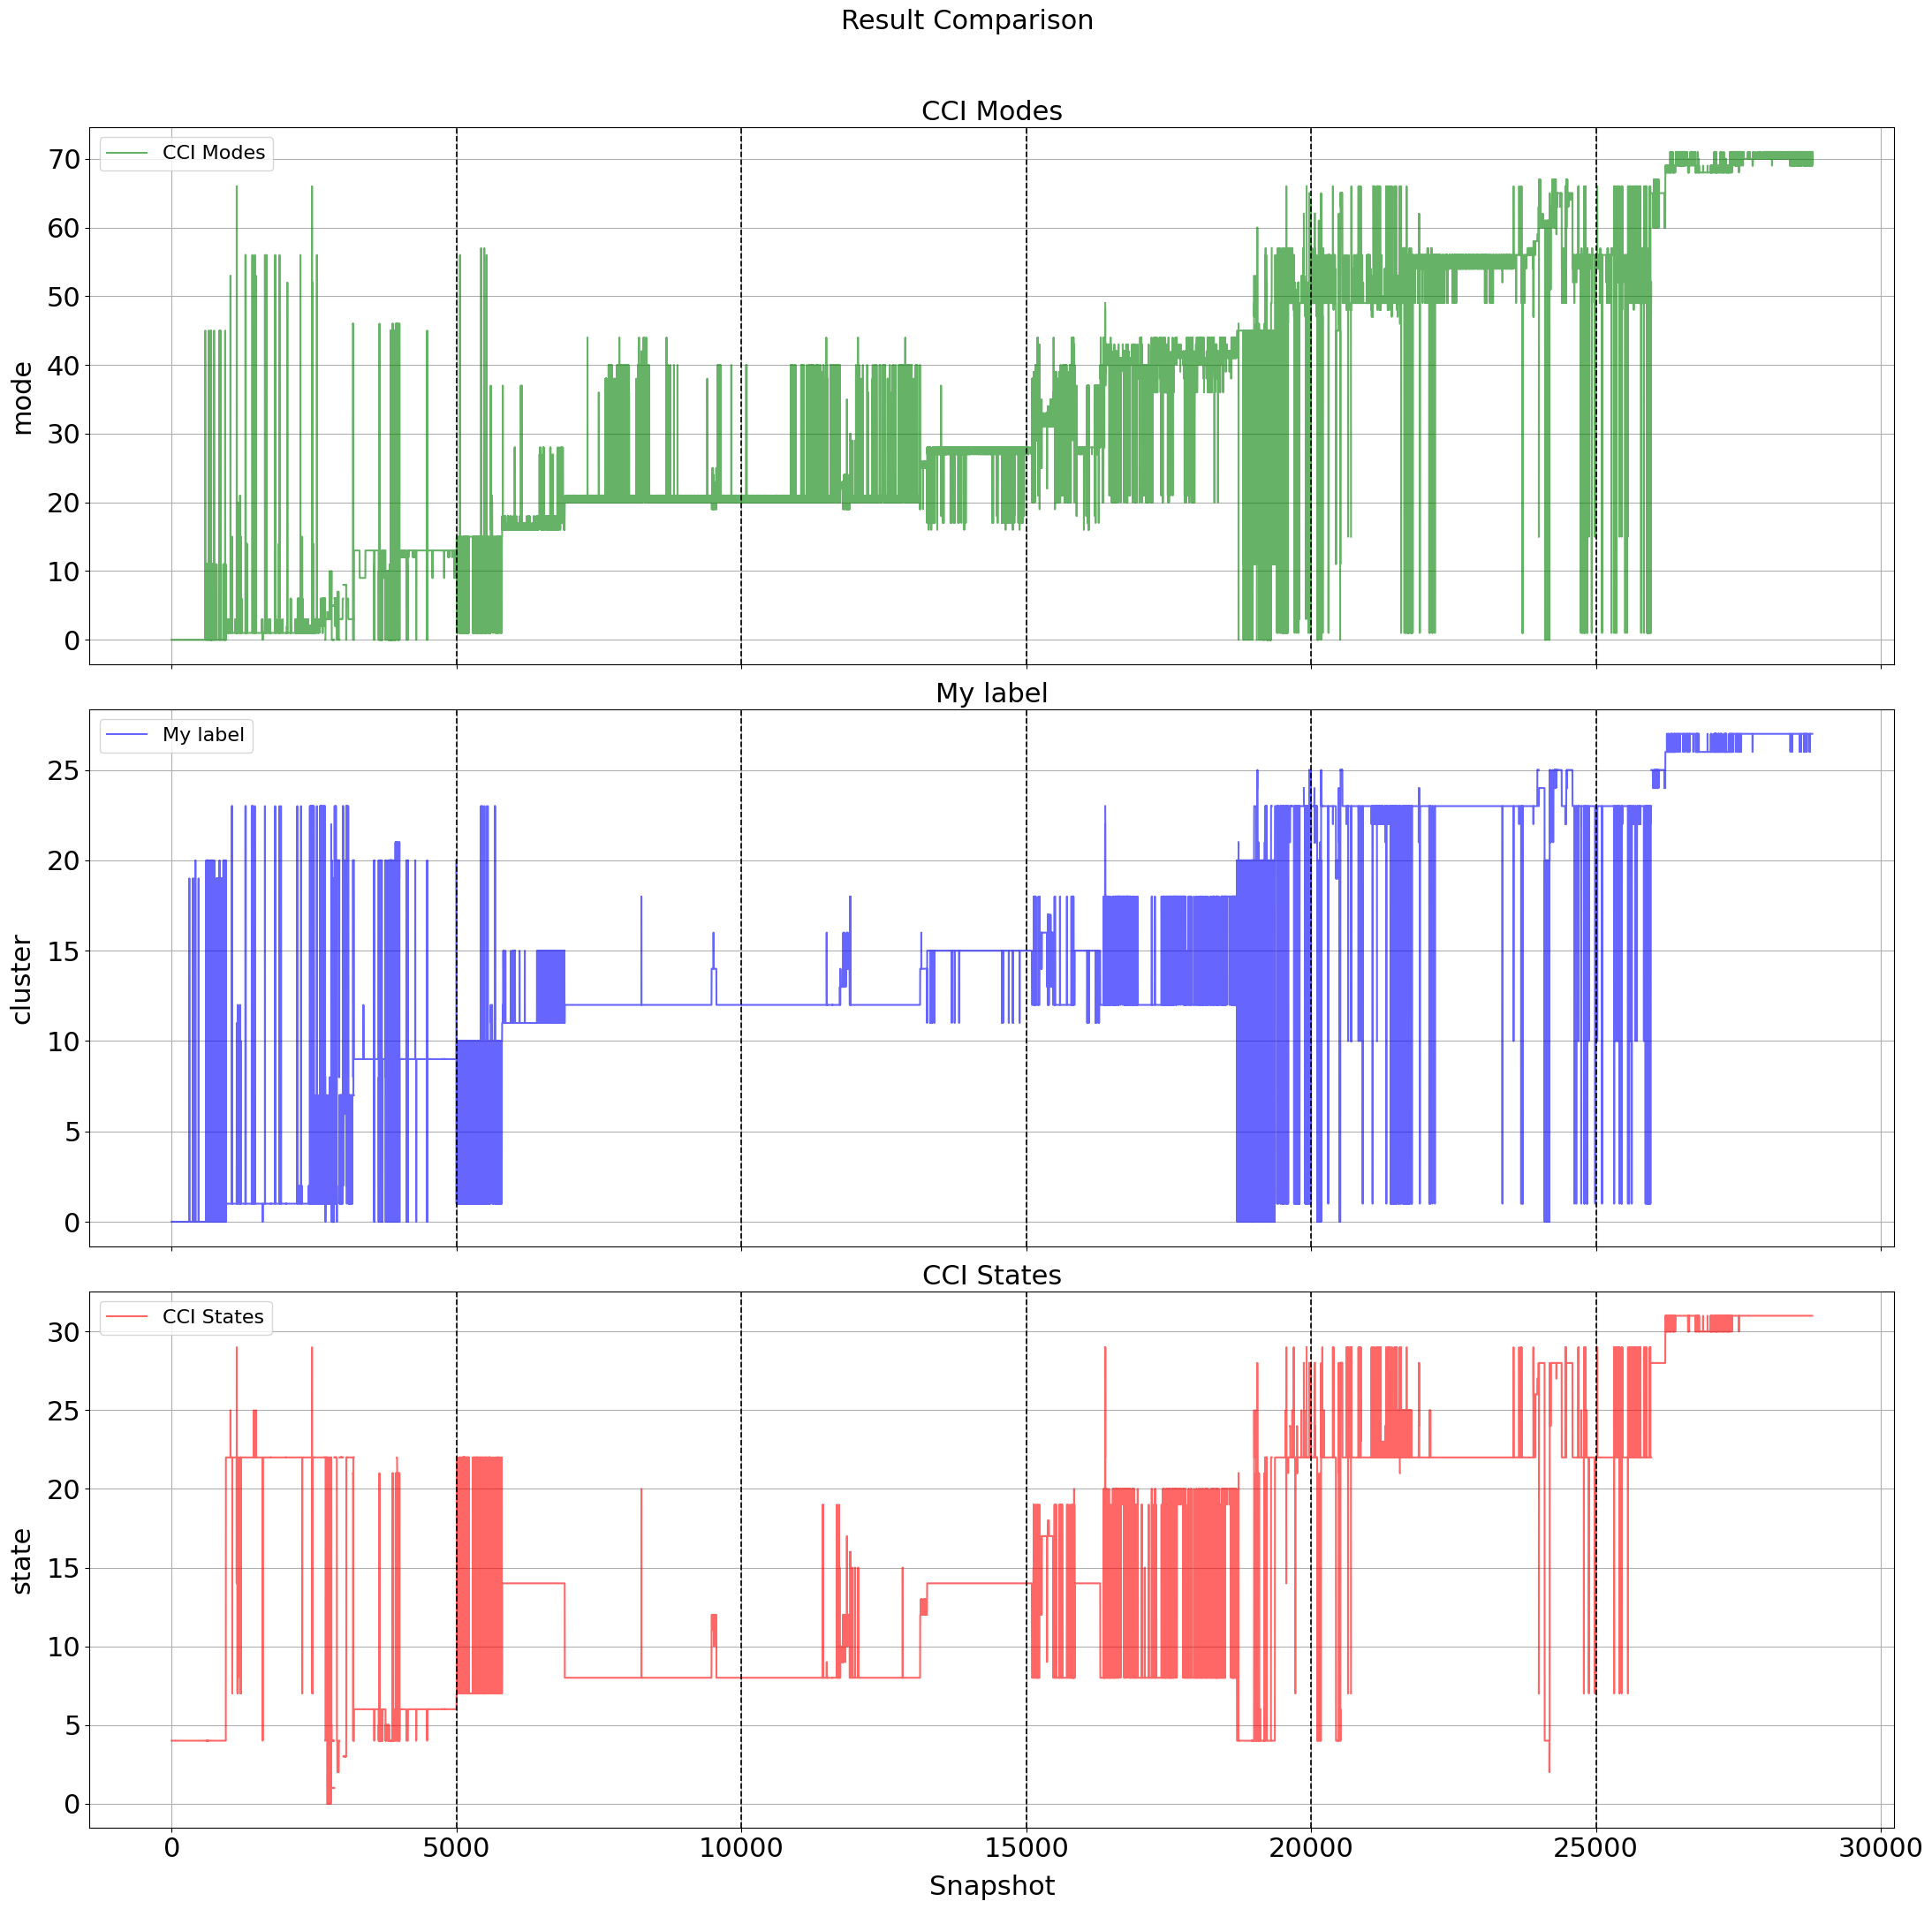

In [10]:
show_idx = np.arange(0, 28800)
compare_xs = [5000, 10000, 15000, 20000, 25000]

fig, axs = plt.subplots(3, 1, figsize=(22, 22), sharex=True)

# Modes
axs[0].plot(modes[show_idx], label='CCI Modes', alpha=0.6, color='green')
axs[0].legend(fontsize=16) 
axs[0].set_title("CCI Modes", fontsize=22)

# My label
axs[1].plot(labels[show_idx], label='My label', alpha=0.6, color='blue')
axs[1].legend(fontsize=16)
axs[1].set_title("My label", fontsize=22)

# States
axs[2].plot(states[show_idx], label='CCI States', alpha=0.6, color='red')
axs[2].legend(fontsize=16)
axs[2].set_title("CCI States", fontsize=22)

# 
axs[0].set_ylabel('mode', fontsize=22, labelpad=10) 
axs[1].set_ylabel('cluster', fontsize=22, labelpad=10) 
axs[2].set_ylabel('state', fontsize=22, labelpad=10) 
for ax in axs:
    ax.tick_params(axis='both', labelsize=22)         
    ax.grid(True)
    for x in compare_xs:
        ax.axvline(x=x, color='black', linestyle='--', linewidth=1.2)

axs[2].set_xlabel('Snapshot', fontsize=22, labelpad=10)
fig.suptitle("Result Comparison", fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



C:\Users\sunhw\AppData\Local\Temp\ipykernel_53468\3339560211.py:39: RuntimeWarning: invalid value encountered in divide
  spread_percentage = spread / nr_frames


Your total assignment error: 4.54 %
Your total assignment error: 7.29 %
Your total assignment error: 44.09 %


np.float64(44.09435081475278)

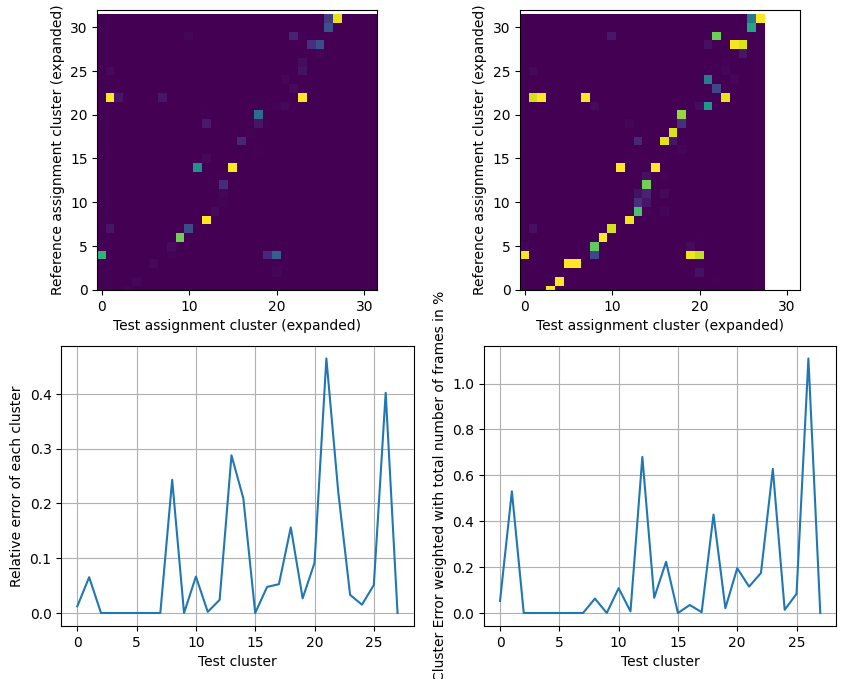

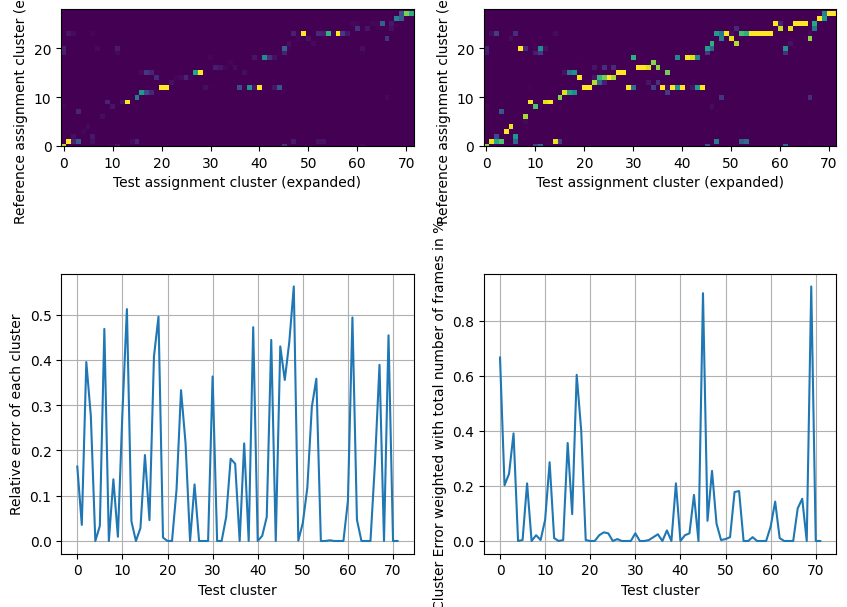

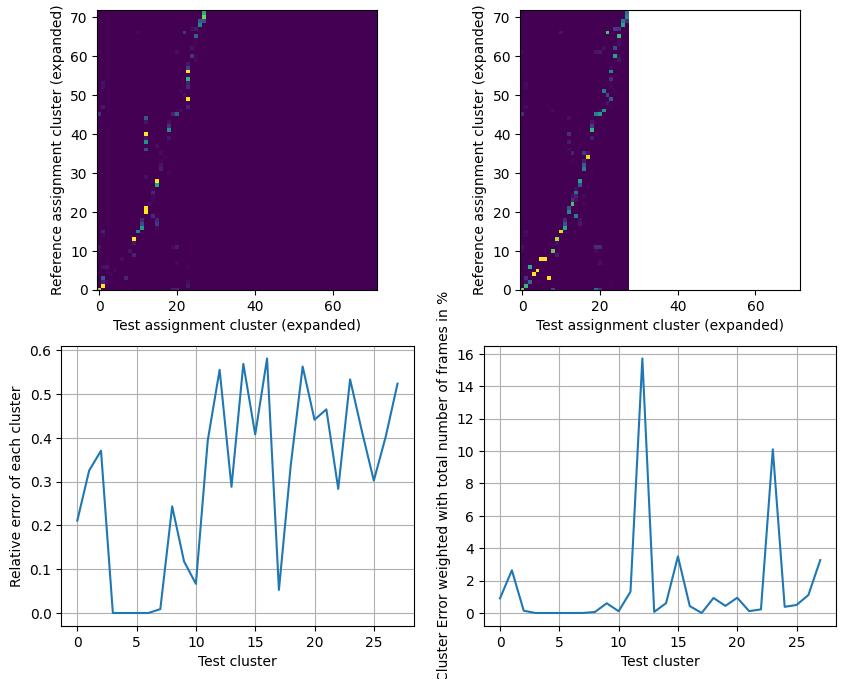

In [11]:
def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Which clusters do we have?
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz = np.max(
        [
            len(clusters_test),
            len(clusters_ref),
        ]
    )

    # Split test clusters
    test_cluster_matrix = np.zeros(
        (sz, sz, len(test_assignment)),
        dtype=bool,
    )
    for i in range(len(clusters_test)):
        tmp = test_assignment == i
        test_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Split reference clusters
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    ref_cluster_matrix = np.zeros((sz, len(reference_assignment)))
    for i in range(len(clusters_ref)):
        tmp = reference_assignment == i
        ref_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Compare test and reference clusters
    comparison = test_cluster_matrix * ref_cluster_matrix[np.newaxis, ...]

    # What is the percentage of overlap of each cluster?
    spread = np.sum(comparison, axis=-1)
    nr_frames = np.sum(test_cluster_matrix, axis=-1)
    spread_percentage = spread / nr_frames
    spread_percentage[np.isinf(spread_percentage)] = 0

    # What is the error_rate?
    error = 1 - np.max(spread_percentage, axis=-1)
    error_rate = error * (nr_frames[:, 0] / np.sum(nr_frames[:, 0]))
    total_error = np.nansum(error_rate)

    # To-do: Put into pandas dataframe

    # Create some nice plots
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))


    mi, ma = np.nanpercentile(spread[spread != 0], [5, 95])
    m00 = ax[0, 0].imshow(np.transpose(spread), vmin=mi, vmax=ma)
    ax[0, 0].set_ylabel("Reference assignment cluster (expanded)")
    ax[0, 0].set_xlabel("Test assignment cluster (expanded)")
    ax[0, 0].set_ylim([0, len(clusters_ref)])
    # cb00 = plt.colorbar(m00, label="Distribution in reference clusters")

    mi, ma = np.nanpercentile(spread_percentage[spread_percentage != 0], [1, 99])
    m01 = ax[0, 1].imshow(np.transpose(spread_percentage), vmin=mi, vmax=ma)
    ax[0, 1].set_ylabel("Reference assignment cluster (expanded)")
    ax[0, 1].set_xlabel("Test assignment cluster (expanded)")
    ax[0, 1].set_ylim([0, len(clusters_ref)])
    # cb01 = plt.colorbar(m01, label="Distribution in reference clusters in %")

    ax[1, 0].plot(error)
    ax[1, 0].grid()
    ax[1, 0].set_xlabel("Test cluster")
    ax[1, 0].set_ylabel("Relative error of each cluster")

    ax[1, 1].plot(100 * error_rate)
    ax[1, 1].grid()
    ax[1, 1].set_xlabel("Test cluster")
    ax[1, 1].set_ylabel("Cluster Error weighted with total number of frames in %")

    print("Your total assignment error: %.2f %%" % (100 * total_error))

    return 100 * total_error
benchmark_assignment(labels,states)
benchmark_assignment(modes,labels)
benchmark_assignment(labels,modes)

In [12]:
def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Which clusters do we have?
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz = np.max([len(clusters_test), len(clusters_ref)])

    # Split test clusters
    test_cluster_matrix = np.zeros((sz, sz, len(test_assignment)), dtype=bool)
    for i in range(len(clusters_test)):
        tmp = test_assignment == i
        test_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Split reference clusters
    ref_cluster_matrix = np.zeros((sz, len(reference_assignment)))
    for i in range(len(clusters_ref)):
        tmp = reference_assignment == i
        ref_cluster_matrix[i, :] = tmp[np.newaxis, :]

    # Compare test and reference clusters
    comparison = test_cluster_matrix * ref_cluster_matrix[np.newaxis, ...]

    # Percentage overlap
    spread = np.sum(comparison, axis=-1)
    nr_frames = np.sum(test_cluster_matrix, axis=-1)
    spread_percentage = spread / nr_frames
    spread_percentage[np.isinf(spread_percentage)] = 0

    # Error rate
    error = 1 - np.max(spread_percentage, axis=-1)
    error_rate = error * (nr_frames[:, 0] / np.sum(nr_frames[:, 0]))
    total_error = np.nansum(error_rate)

    # --- Create summary table ---
    df = pd.DataFrame({
        "Test Cluster": np.arange(len(clusters_test)),
        "Frames": nr_frames[:, 0],
        "Best Overlap %": np.max(spread_percentage, axis=-1),
        "Relative Error": error,
        "Weighted Error %": 100 * error_rate,
    })

    print(df.to_string(index=False))
    print("\nYour total assignment error: %.2f %%" % (100 * total_error))

    return df, 100 * total_error
benchmark_assignment(labels,states)

C:\Users\sunhw\AppData\Local\Temp\ipykernel_53468\2294738052.py:29: RuntimeWarning: invalid value encountered in divide
  spread_percentage = spread / nr_frames


ValueError: All arrays must be of the same length

In [22]:
def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Which clusters do we have?
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz_test = len(clusters_test)
    sz_ref = len(clusters_ref)

    # Build contingency matrix
    contingency = np.zeros((sz_test, sz_ref), dtype=int)
    for i, ct in enumerate(clusters_test):
        for j, cr in enumerate(clusters_ref):
            contingency[i, j] = np.sum((test_assignment == ct) & (reference_assignment == cr))

    # Normalize rows to percentages (relative distribution of each test cluster across reference clusters)
    contingency_pct = contingency / contingency.sum(axis=1, keepdims=True)
    contingency_pct[np.isnan(contingency_pct)] = 0

    # Build DataFrame
    df_counts = pd.DataFrame(
        contingency,
        index=[f"Test {ct}" for ct in clusters_test],
        columns=[f"Ref {cr}" for cr in clusters_ref],
    )
    df_pct = pd.DataFrame(
        np.round(100 * contingency_pct, 2),
        index=[f"Test {ct}" for ct in clusters_test],
        columns=[f"Ref {cr}" for cr in clusters_ref],
    )

    print("Cluster overlap counts:")
    print(df_counts.to_string())
    print("\nCluster overlap percentages (row-normalized):")
    print(df_pct.to_string())

    return df_counts, df_pct

benchmark_assignment(labels,states)

Cluster overlap counts:
           Ref 0.0  Ref 1.0  Ref 2.0  Ref 3.0  Ref 4.0  Ref 5.0  Ref 6.0  Ref 7.0  Ref 8.0  Ref 9.0  Ref 10.0  Ref 11.0  Ref 12.0  Ref 13.0  Ref 14.0  Ref 15.0  Ref 16.0  Ref 17.0  Ref 18.0  Ref 19.0  Ref 20.0  Ref 21.0  Ref 22.0  Ref 23.0  Ref 24.0  Ref 25.0  Ref 26.0  Ref 27.0  Ref 28.0  Ref 29.0  Ref 30.0  Ref 31.0
Test 0.0         0        0        0        0      784        1        0        0        0        0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0         0
Test 1.0         0        0        0        0        0        0        0       24        0        0         0         0         0         0         0         0         0         0         0         0         0         0      1773         0         0        30         0         0         0         2         0         0
Test 2.0        

(           Ref 0.0  Ref 1.0  Ref 2.0  Ref 3.0  Ref 4.0  Ref 5.0  Ref 6.0  \
 Test 0.0         0        0        0        0      784        1        0   
 Test 1.0         0        0        0        0        0        0        0   
 Test 2.0         0        0        0        0        0        0        0   
 Test 3.0         0        0        0        0        0        0        0   
 Test 4.0        18        1        0        0        0        0        0   
 ...            ...      ...      ...      ...      ...      ...      ...   
 Test 68.0        0        0        0        0        0        0        0   
 Test 69.0        0        0        0        0        0        0        0   
 Test 70.0        0        0        0        0        0        0        0   
 Test 71.0        0        0        0        0        0        0        0   
 Test 72.0        0        0        0        0        0        0        0   
 
            Ref 7.0  Ref 8.0  Ref 9.0  ...  Ref 22.0  Ref 23.0  Ref 24.0  

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Which clusters do we have?
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz_test = len(clusters_test)
    sz_ref = len(clusters_ref)

    # Build contingency matrix
    contingency = np.zeros((sz_test, sz_ref), dtype=int)
    for i, ct in enumerate(clusters_test):
        for j, cr in enumerate(clusters_ref):
            contingency[i, j] = np.sum((test_assignment == ct) & (reference_assignment == cr))

    # Normalize rows to percentages (relative distribution of each test cluster across reference clusters)
    contingency_pct = contingency / contingency.sum(axis=1, keepdims=True)
    contingency_pct[np.isnan(contingency_pct)] = 0

    # Build DataFrames
    df_counts = pd.DataFrame(
        contingency,
        index=[f"Cluster {ct}" for ct in clusters_test],
        columns=[f"State {cr}" for cr in clusters_ref],
    )
    df_pct = pd.DataFrame(
        np.round(100 * contingency_pct, 2),
        index=[f"Cluster {ct}" for ct in clusters_test],
        columns=[f"State {cr}" for cr in clusters_ref],
    )

    print("Cluster overlap counts:")
    print(df_counts.to_string())
    print("\nCluster overlap percentages (row-normalized):")
    print(df_pct.to_string())


    df_colnorm = df_counts / df_counts.max(axis=0)
    df_rownorm = df_counts.div(df_counts.max(axis=1), axis=0)

    plt.figure(figsize=(28, 28))
    sns.heatmap(df_rownorm[::-1], annot=df_counts[::-1], fmt="d", cmap="Blues")
    plt.title("Contingency Matrix", fontsize=14)
    plt.xlabel("My clusters")
    plt.ylabel("CCI states")
    plt.tight_layout()
    plt.show()


    return df_counts, df_pct



Cluster overlap counts:
              State 0.0  State 1.0  State 2.0  State 3.0  State 4.0  State 5.0  State 6.0  State 7.0  State 8.0  State 9.0  State 10.0  State 11.0  State 12.0  State 13.0  State 14.0  State 15.0  State 16.0  State 17.0  State 18.0  State 19.0  State 20.0  State 21.0  State 22.0  State 23.0  State 24.0  State 25.0  State 26.0  State 27.0  State 28.0  State 29.0  State 30.0  State 31.0
Cluster 0.0           0          0          0          0        784          1          0          0          0          0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0
Cluster 1.0           0          0          0          0          0          0          0         24          0          0           0           0           0           0           0           0        

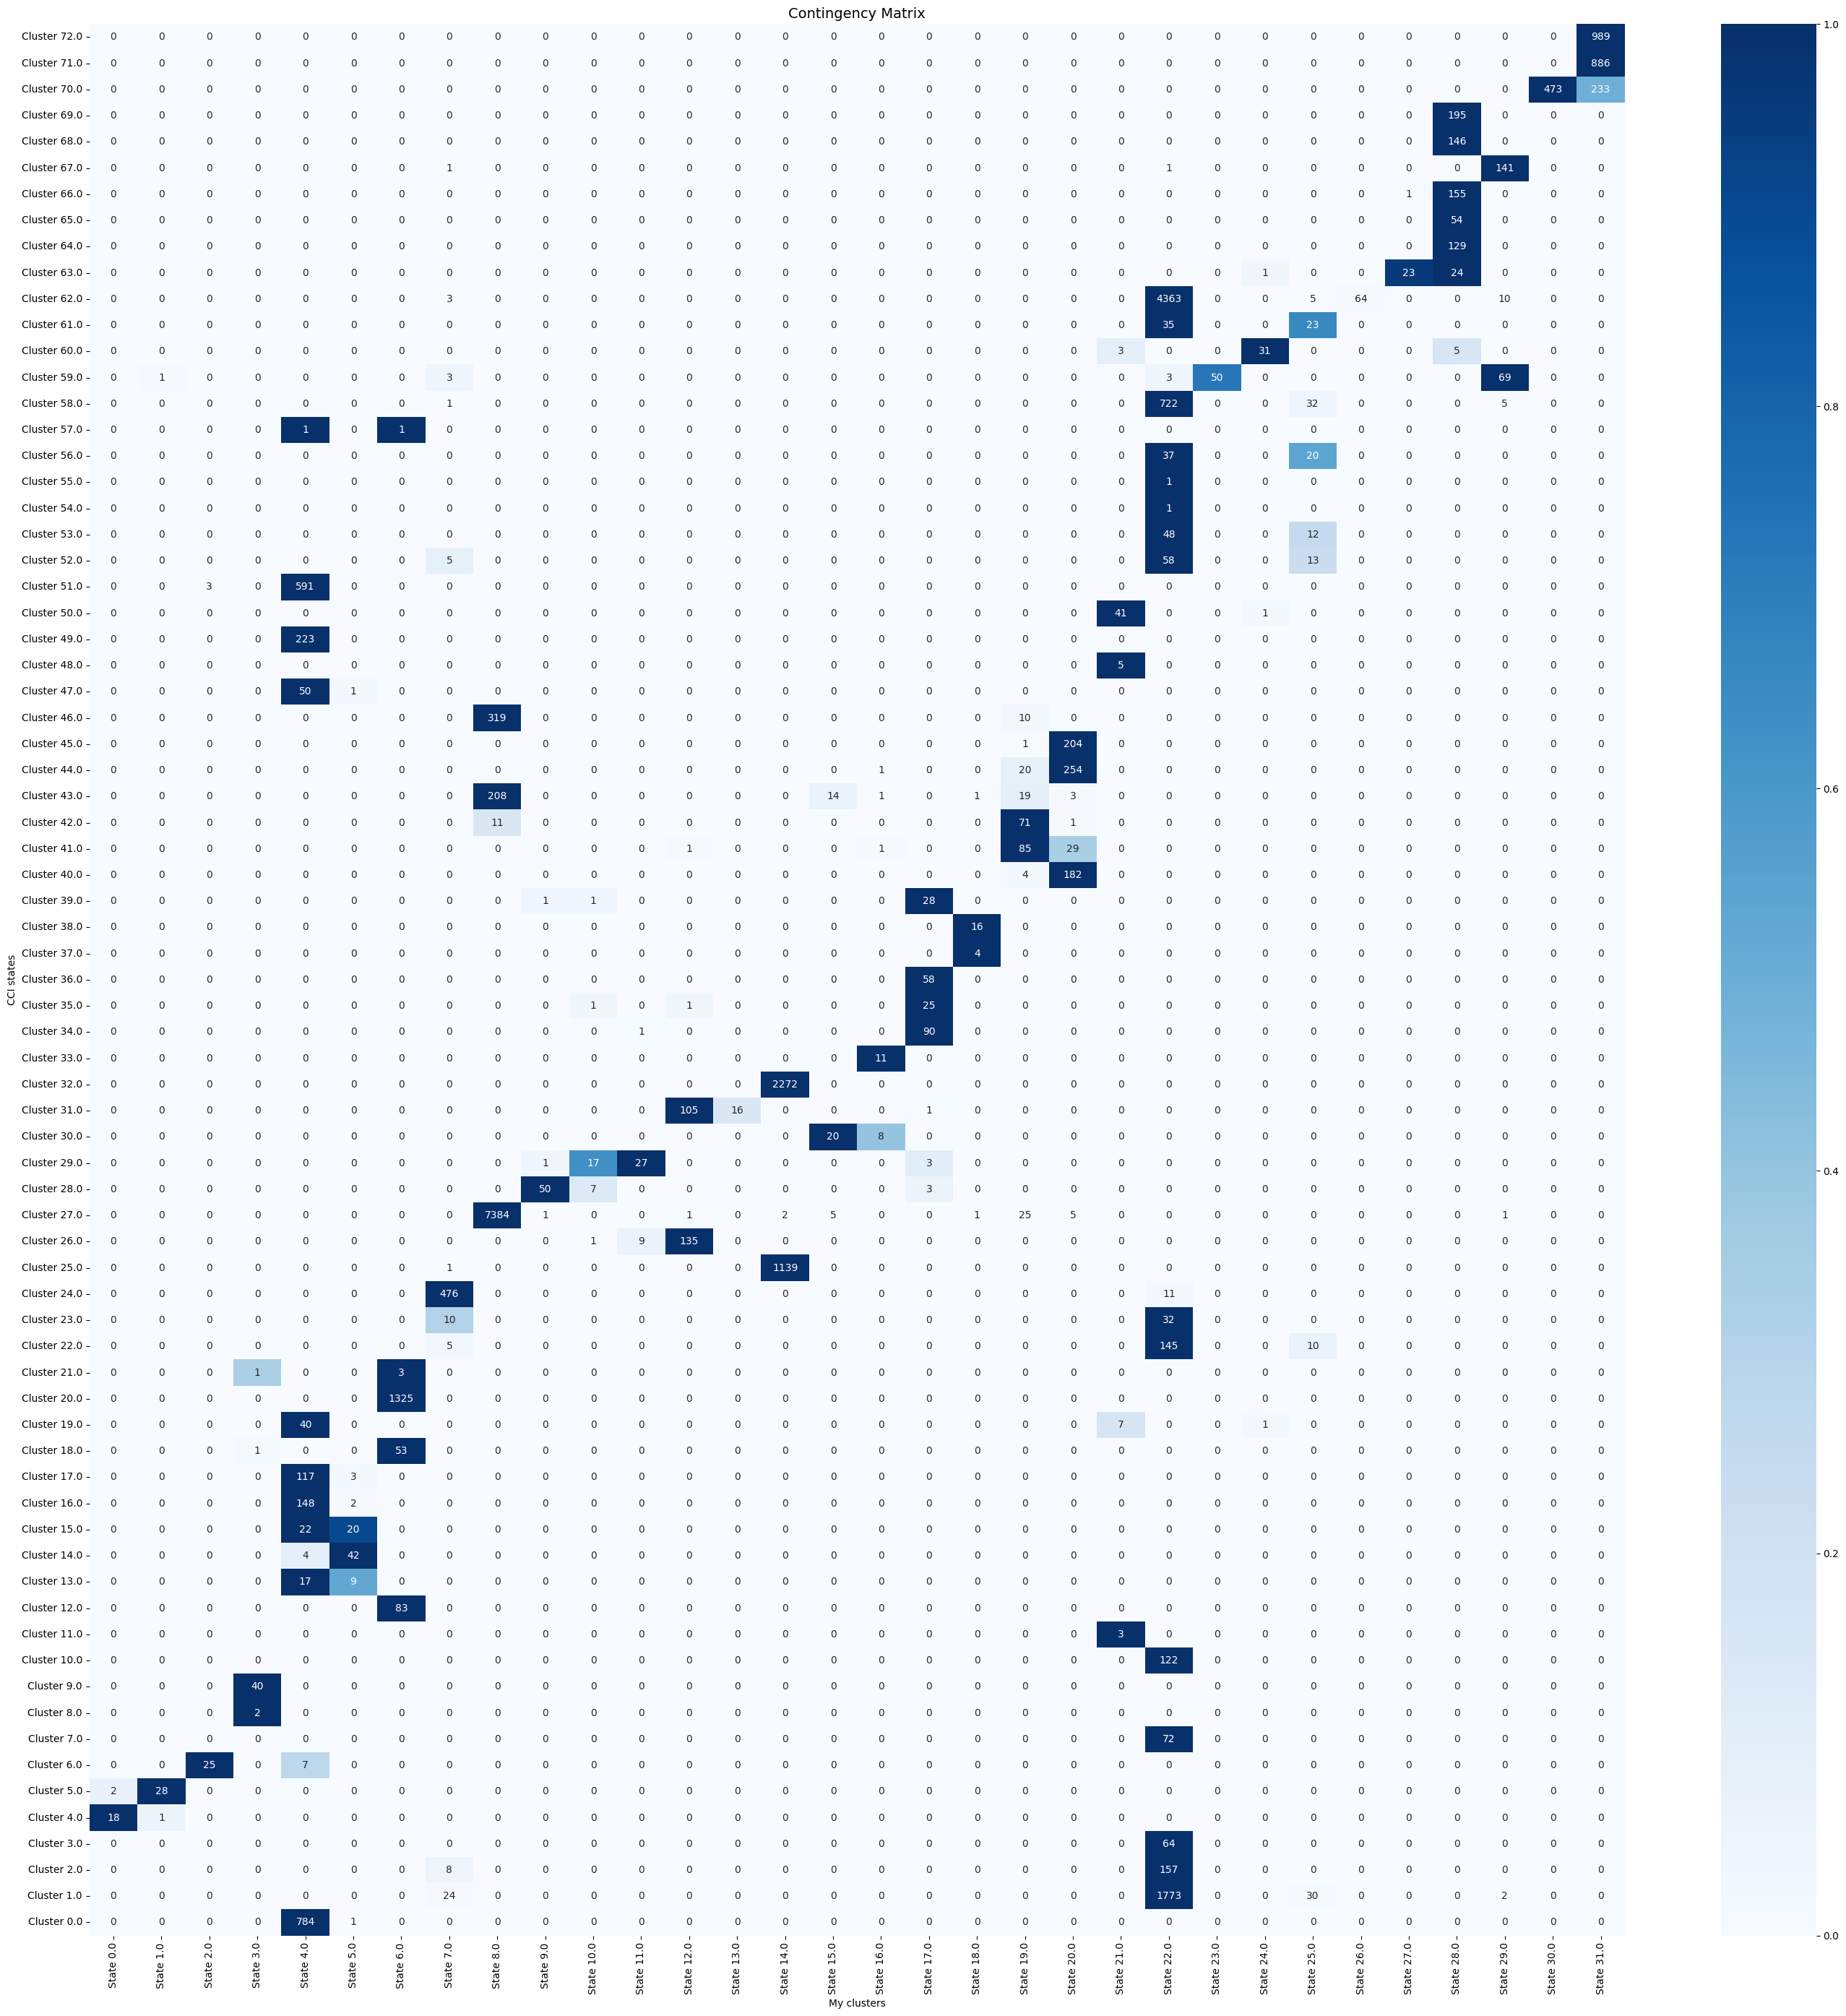

(              State 0.0  State 1.0  State 2.0  State 3.0  State 4.0  \
 Cluster 0.0           0          0          0          0        784   
 Cluster 1.0           0          0          0          0          0   
 Cluster 2.0           0          0          0          0          0   
 Cluster 3.0           0          0          0          0          0   
 Cluster 4.0          18          1          0          0          0   
 ...                 ...        ...        ...        ...        ...   
 Cluster 68.0          0          0          0          0          0   
 Cluster 69.0          0          0          0          0          0   
 Cluster 70.0          0          0          0          0          0   
 Cluster 71.0          0          0          0          0          0   
 Cluster 72.0          0          0          0          0          0   
 
               State 5.0  State 6.0  State 7.0  State 8.0  State 9.0  ...  \
 Cluster 0.0           1          0          0          0

In [24]:
benchmark_assignment(labels,states)

Cluster overlap counts:
              State 0.0  State 1.0  State 2.0  State 3.0  State 4.0  State 5.0  State 6.0  State 7.0  State 8.0  State 9.0  State 10.0  State 11.0  State 12.0  State 13.0  State 14.0  State 15.0  State 16.0  State 17.0  State 18.0  State 19.0  State 20.0  State 21.0  State 22.0  State 23.0  State 24.0  State 25.0  State 26.0  State 27.0  State 28.0  State 29.0  State 30.0  State 31.0  State 32.0  State 33.0  State 34.0  State 35.0  State 36.0  State 37.0  State 38.0  State 39.0  State 40.0  State 41.0  State 42.0  State 43.0  State 44.0  State 45.0  State 46.0  State 47.0  State 48.0  State 49.0  State 50.0  State 51.0  State 52.0  State 53.0  State 54.0  State 55.0  State 56.0  State 57.0  State 58.0  State 59.0  State 60.0  State 61.0  State 62.0  State 63.0  State 64.0  State 65.0  State 66.0  State 67.0  State 68.0  State 69.0  State 70.0  State 71.0
Cluster 0.0         755          0          0          0          0          0          0          0         

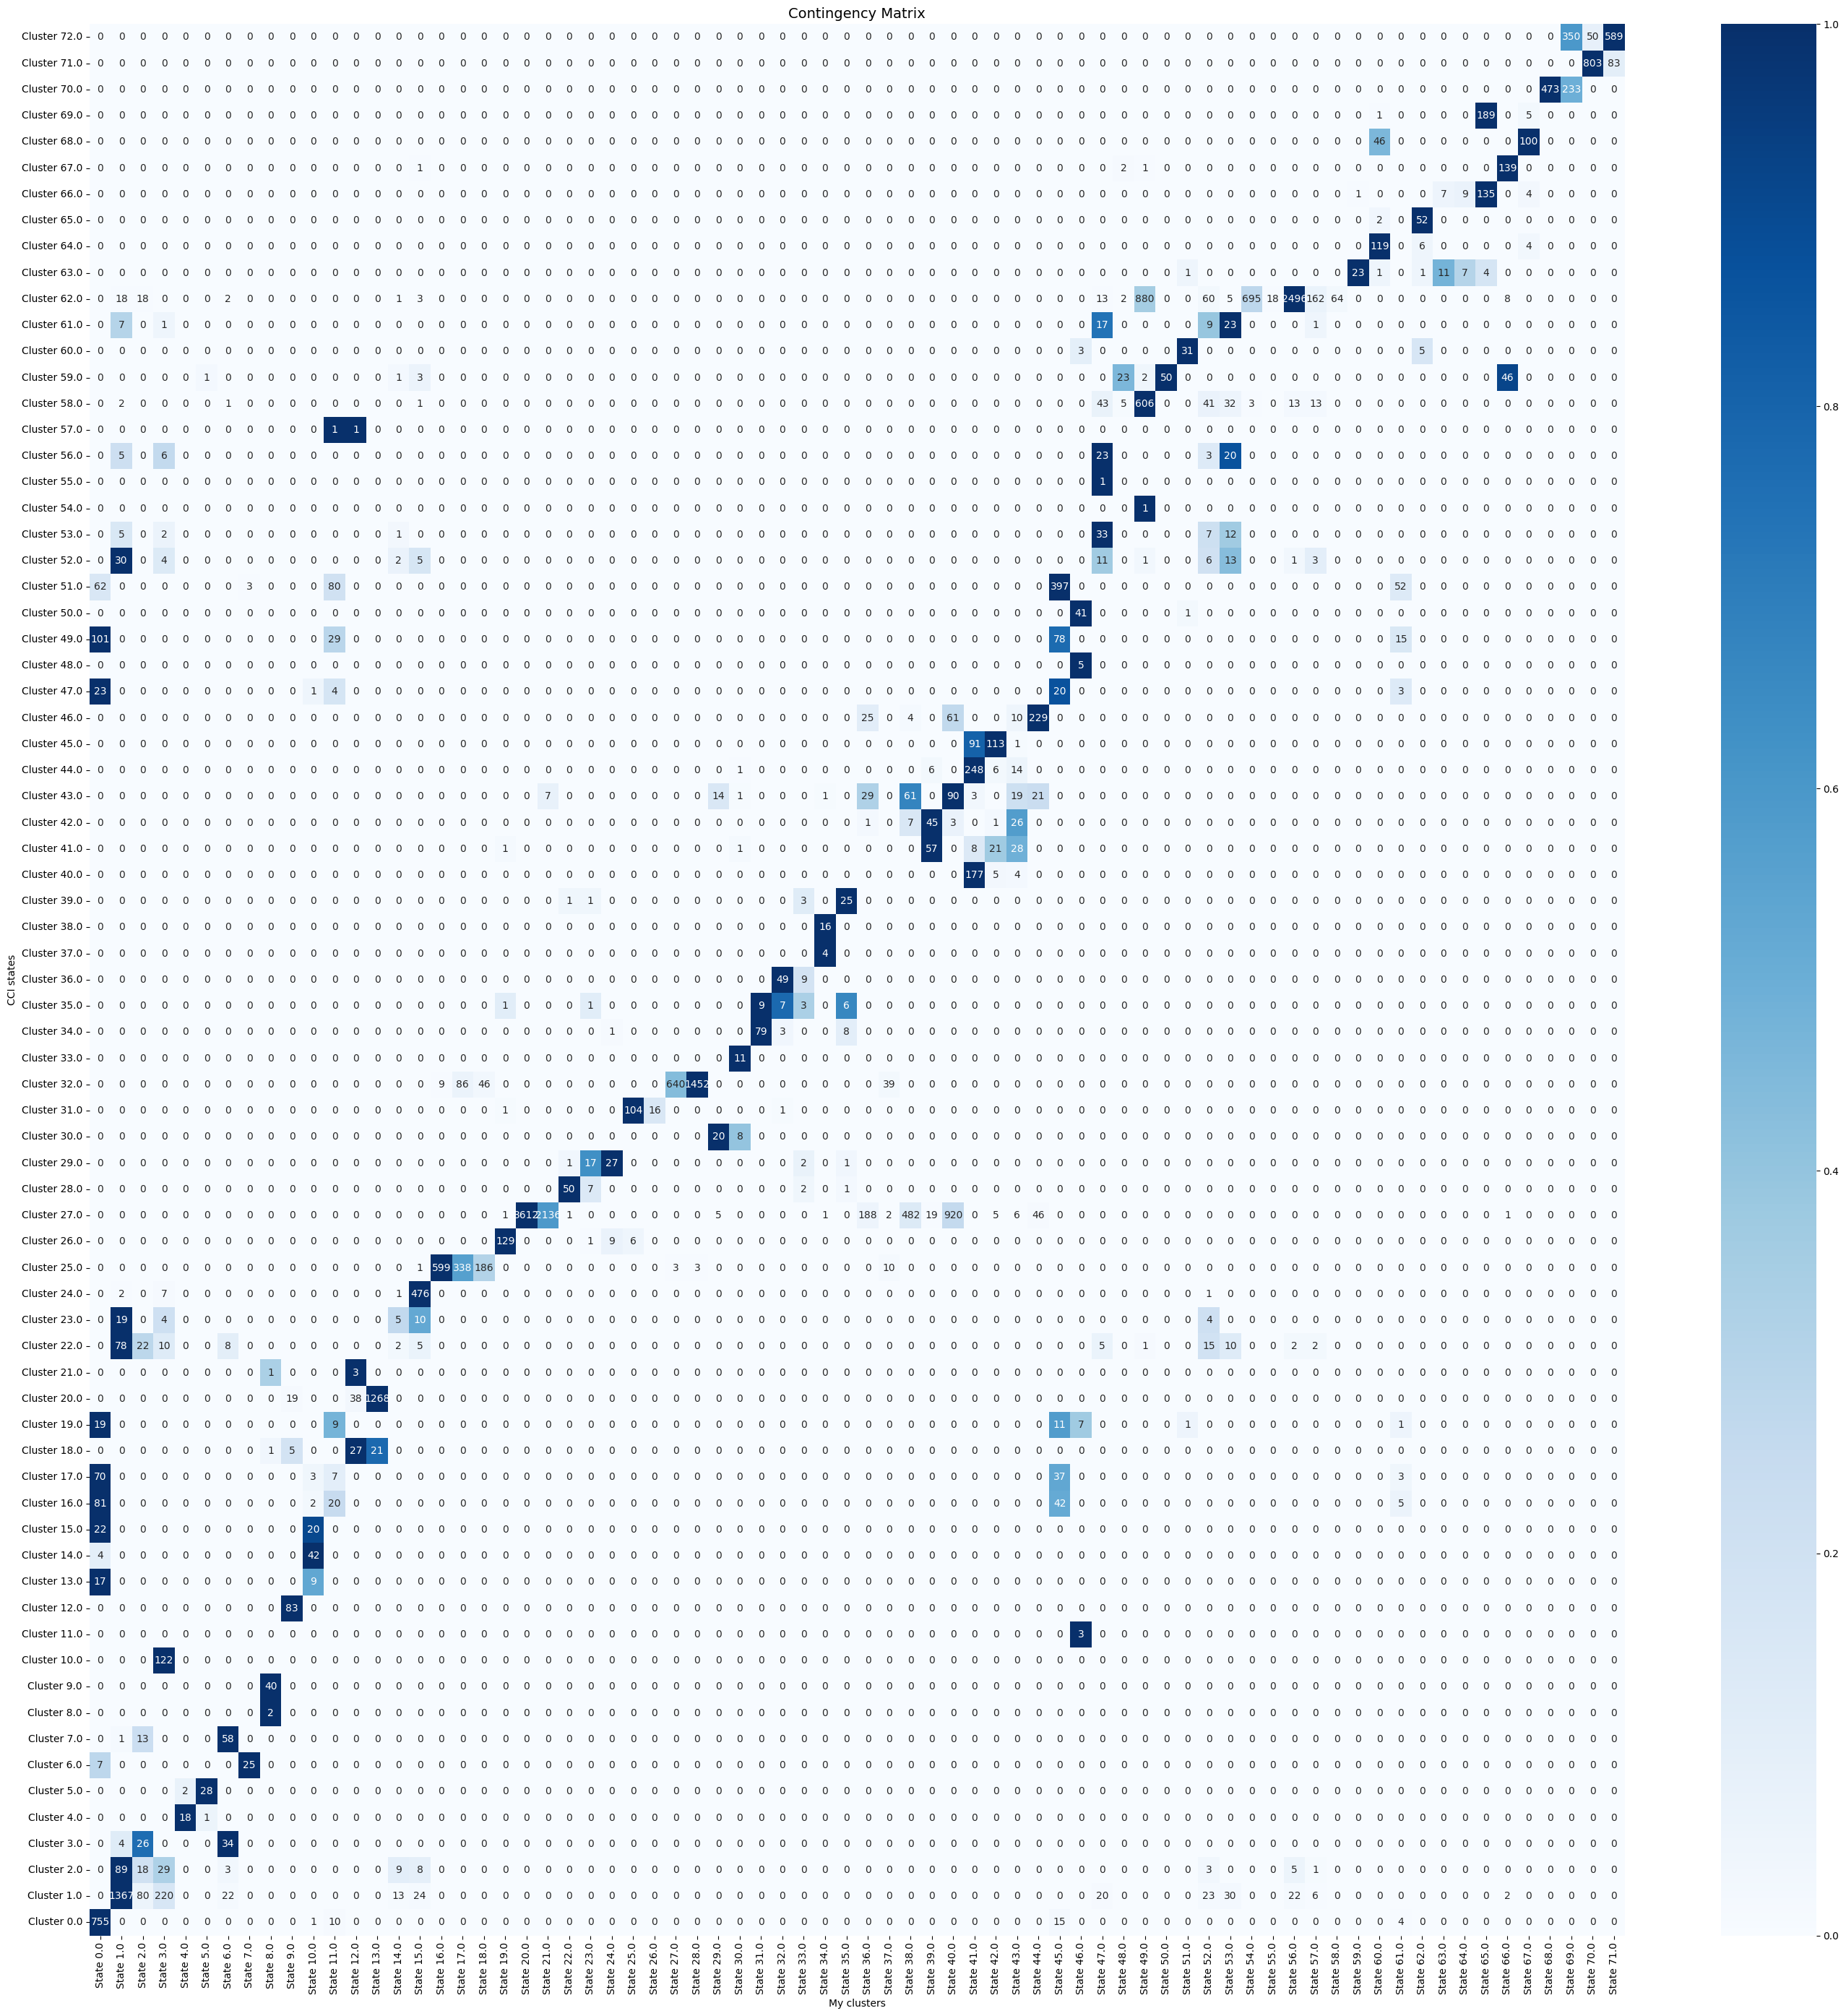

(              State 0.0  State 1.0  State 2.0  State 3.0  State 4.0  \
 Cluster 0.0         755          0          0          0          0   
 Cluster 1.0           0       1367         80        220          0   
 Cluster 2.0           0         89         18         29          0   
 Cluster 3.0           0          4         26          0          0   
 Cluster 4.0           0          0          0          0         18   
 ...                 ...        ...        ...        ...        ...   
 Cluster 68.0          0          0          0          0          0   
 Cluster 69.0          0          0          0          0          0   
 Cluster 70.0          0          0          0          0          0   
 Cluster 71.0          0          0          0          0          0   
 Cluster 72.0          0          0          0          0          0   
 
               State 5.0  State 6.0  State 7.0  State 8.0  State 9.0  ...  \
 Cluster 0.0           0          0          0          0

In [25]:
benchmark_assignment(labels,modes)

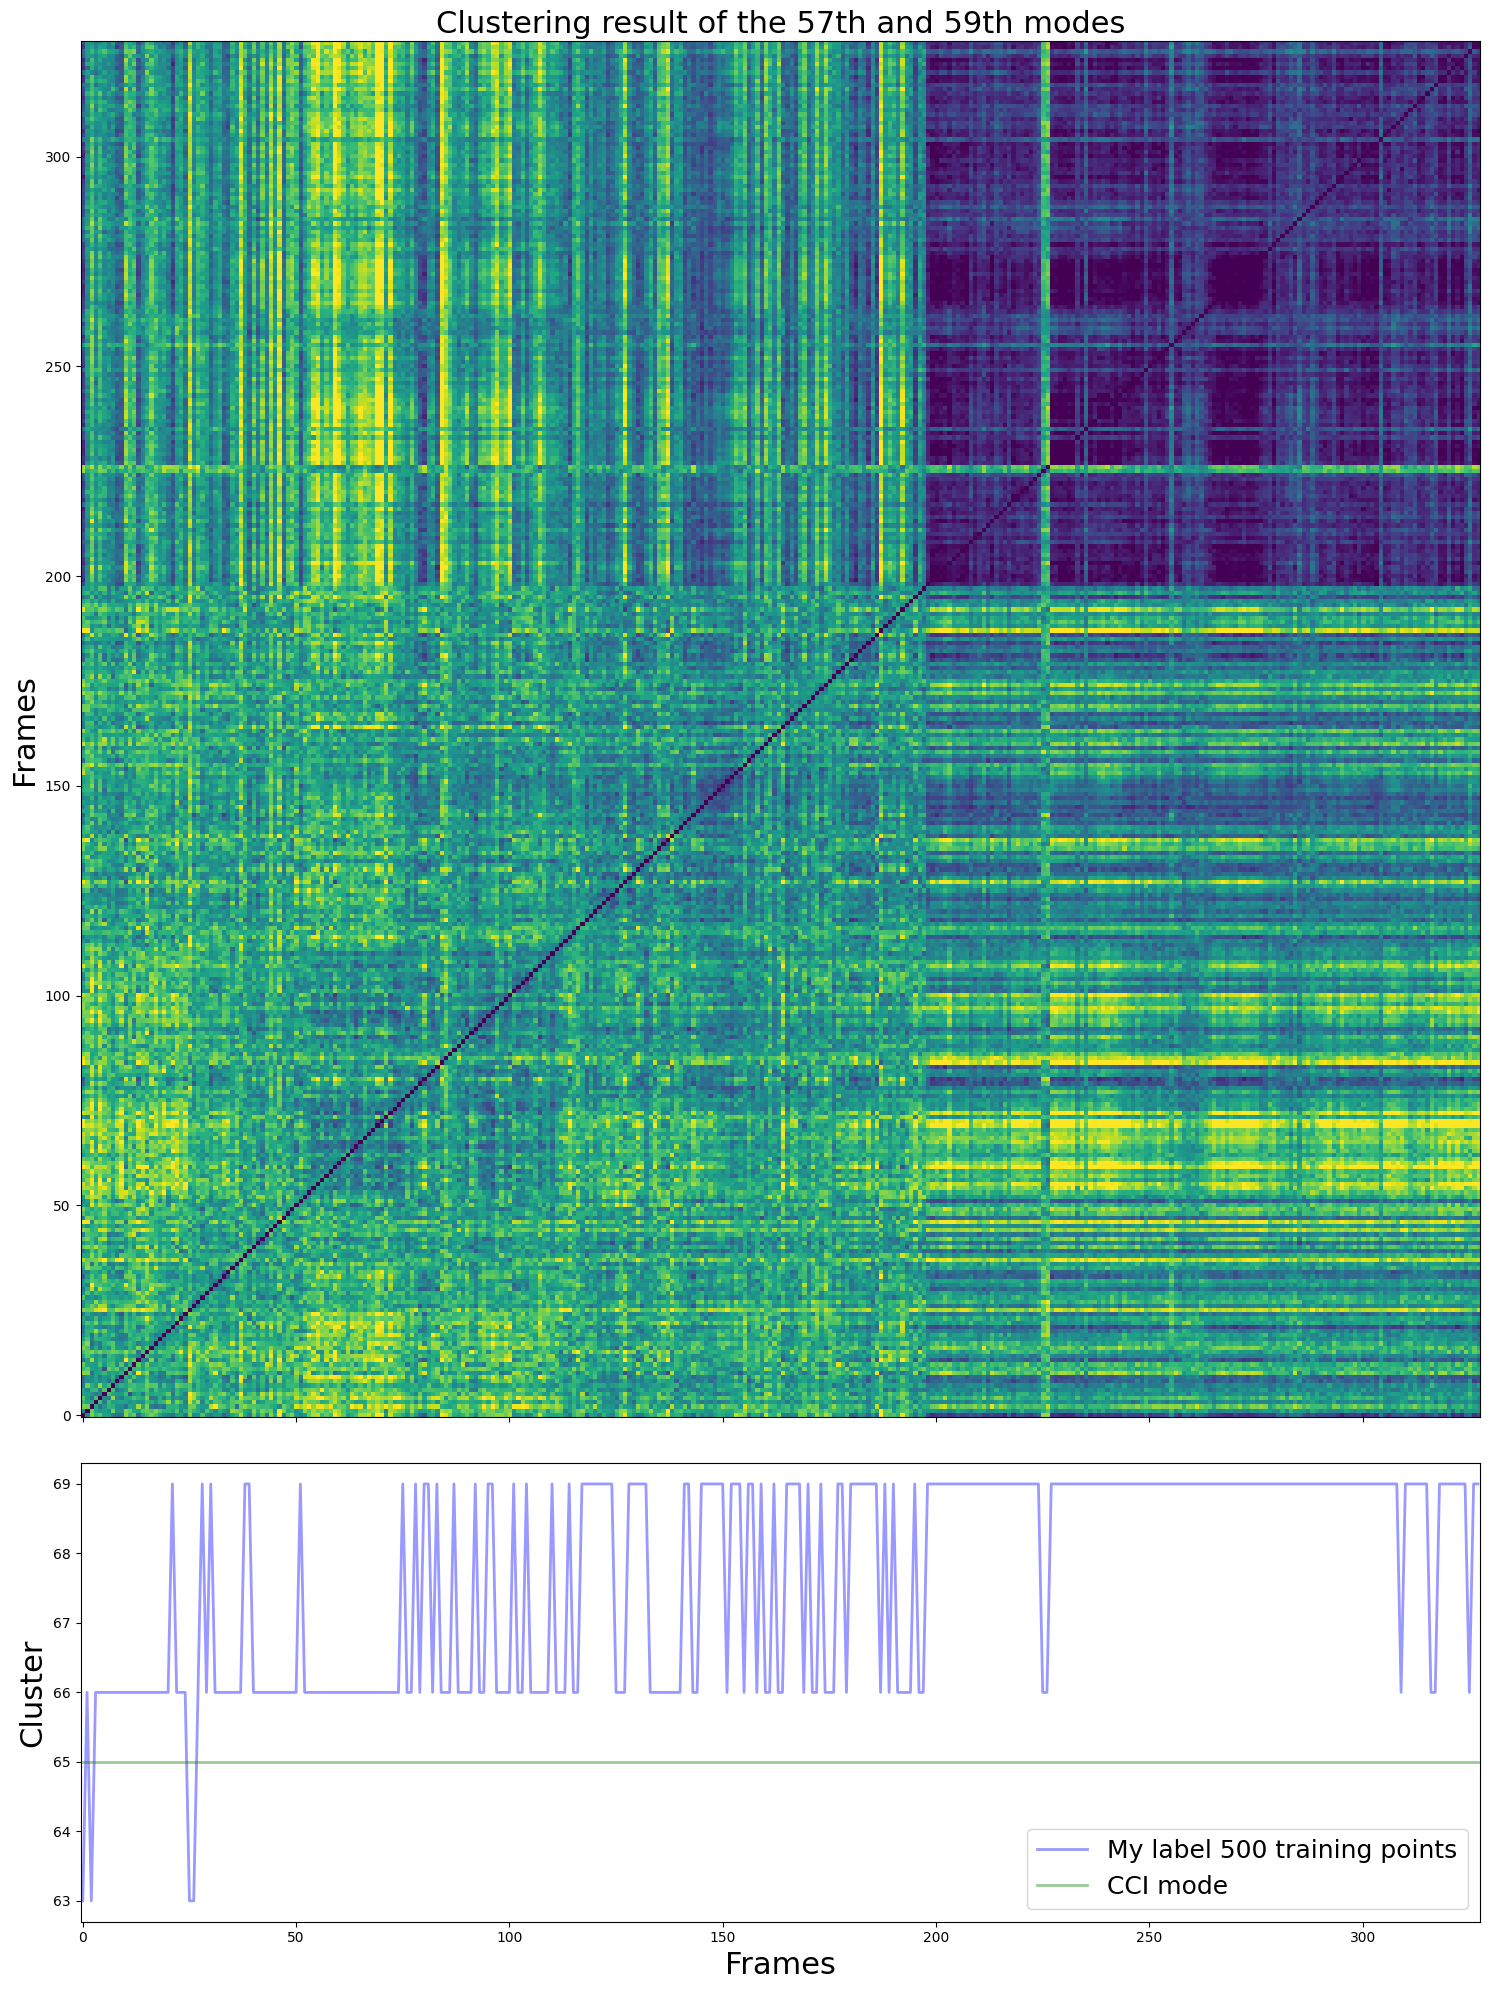

In [42]:
idx_0=np.array(np.where(modes==65))[0]

new_conbine1_idx_2nd_order = SPC.reconstruct_correlation_map(
    idx_0,
    idx_0,
    fragment,
    2,
    "correlation"
)

image_=new_conbine1_idx_2nd_order

# Compute color scale range, excluding near-zero values
vmin, vmax = np.percentile(image_[image_ >= 1e-5], [1, 99])

# Create figure and layout with controlled height ratios
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])  # Top plot 3x taller than bottom

# Create subplots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

# Top plot: second-order correlation map
im = ax0.imshow(
    image_,
    vmin=vmin,
    vmax=vmax,
    #extent=[23000, 25000, 25000, 23000],
    cmap='viridis',
    aspect='auto'
)
#ax0.set_xlim(23000, 25000)
#ax0.set_xlabel("Snapshot", fontsize=20)
ax0.set_ylabel("Frames", fontsize=22)
ax0.set_title("Second-order correlation map of the 57th and 59th modes", fontsize=22)
ax0.tick_params(labelbottom=False)  # Hide x-axis labels to avoid duplication
ax0.invert_yaxis()

# Bottom plot: label sequence 
ax1.plot(labels[idx_0], label='My label 500 training points', alpha=0.4, color='blue',linewidth=2)
ax1.plot(modes[idx_0], label='CCI mode', alpha=0.4, color='green',linewidth=2)
ax1.set_ylabel('Cluster', fontsize=22)
ax1.set_xlabel("Frames", fontsize=22)
ax0.set_title("Clustering result of the 57th and 59th modes", fontsize=22)
ax1.legend(fontsize=18)


# Final layout adjustments

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

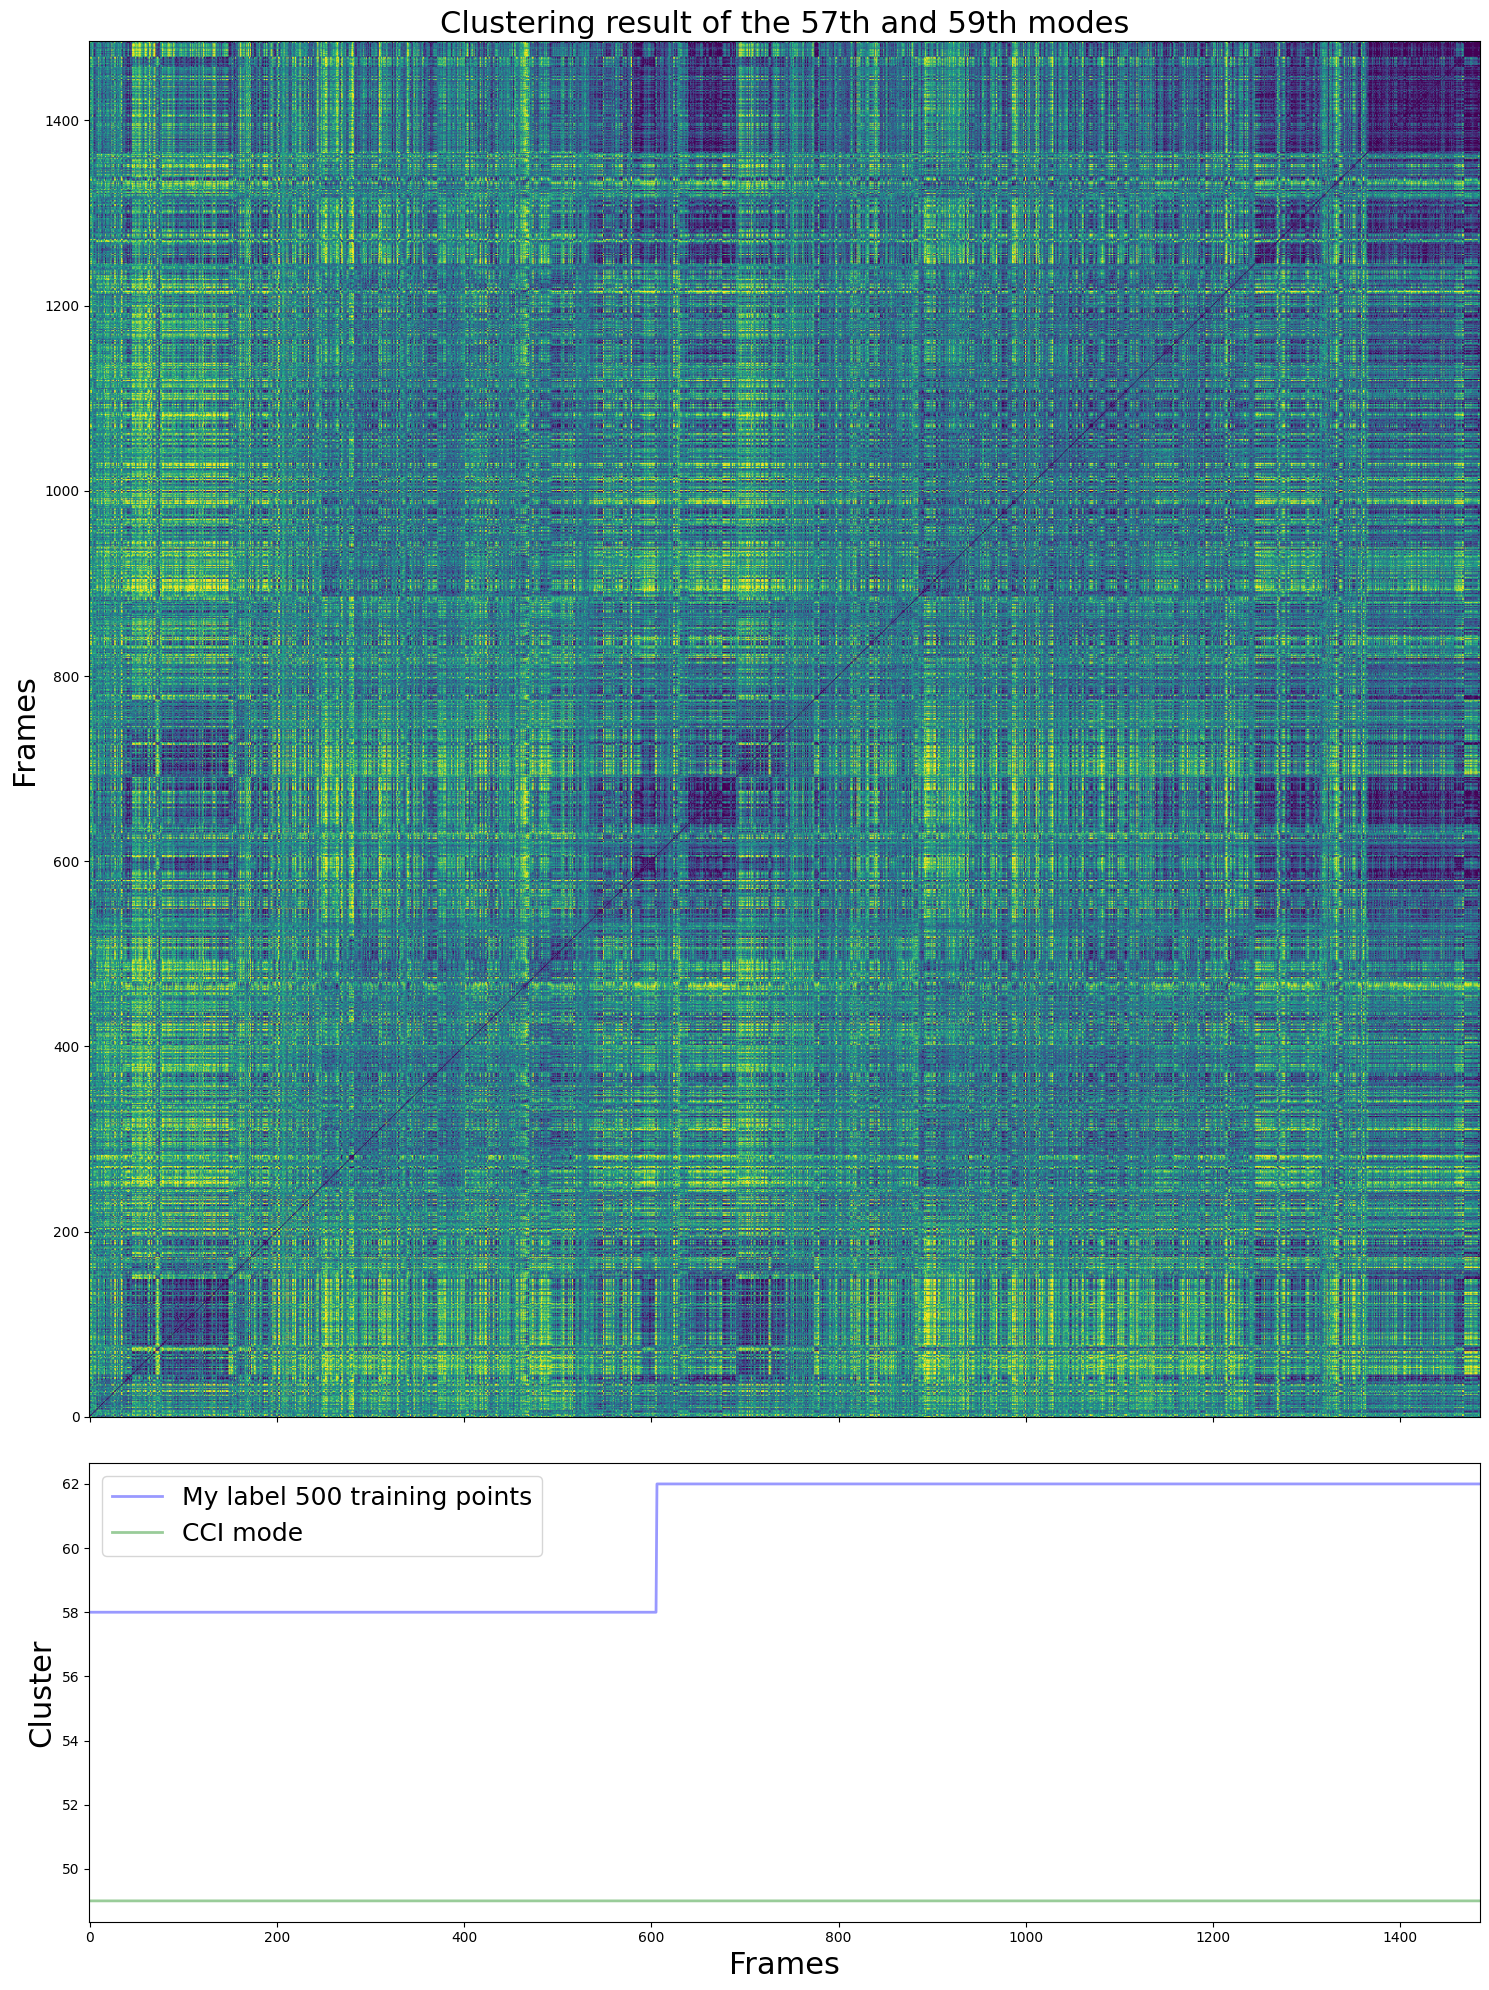

In [35]:
idx_0=np.array(np.where(modes==49))[0]

state1_idx=np.array(np.where(labels==58))[0]
state2_idx=np.array(np.where(labels==62))[0]
new_conbine_idx=np.concatenate((np.intersect1d(idx_0, state1_idx),np.intersect1d(idx_0,state2_idx)))

new_conbine1_idx_2nd_order = SPC.reconstruct_correlation_map(
    new_conbine_idx,
    new_conbine_idx,
    fragment,
    2,
    "correlation"
)

image_=new_conbine1_idx_2nd_order

# Compute color scale range, excluding near-zero values
vmin, vmax = np.percentile(image_[image_ >= 1e-5], [1, 99])

# Create figure and layout with controlled height ratios
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])  # Top plot 3x taller than bottom

# Create subplots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

# Top plot: second-order correlation map
im = ax0.imshow(
    image_,
    vmin=vmin,
    vmax=vmax,
    #extent=[23000, 25000, 25000, 23000],
    cmap='viridis',
    aspect='auto'
)
#ax0.set_xlim(23000, 25000)
#ax0.set_xlabel("Snapshot", fontsize=20)
ax0.set_ylabel("Frames", fontsize=22)
ax0.set_title("Second-order correlation map of the 57th and 59th modes", fontsize=22)
ax0.tick_params(labelbottom=False)  # Hide x-axis labels to avoid duplication
ax0.invert_yaxis()

# Bottom plot: label sequence 
ax1.plot(labels[new_conbine_idx], label='My label 500 training points', alpha=0.4, color='blue',linewidth=2)
ax1.plot(modes[new_conbine_idx], label='CCI mode', alpha=0.4, color='green',linewidth=2)
ax1.set_ylabel('Cluster', fontsize=22)
ax1.set_xlabel("Frames", fontsize=22)
ax0.set_title("Clustering result of the 57th and 59th modes", fontsize=22)
ax1.legend(fontsize=18)


# Final layout adjustments

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

In [33]:
def benchmark_assignment(test_assignment, reference_assignment):
    test_assignment = np.squeeze(test_assignment)
    reference_assignment = np.squeeze(reference_assignment)

    # Identify unique clusters
    clusters_test = np.unique(test_assignment[~np.isnan(test_assignment)])
    clusters_ref = np.unique(reference_assignment[~np.isnan(reference_assignment)])

    sz_test = len(clusters_test)
    sz_ref = len(clusters_ref)

    # Build contingency matrix
    contingency = np.zeros((sz_test, sz_ref), dtype=int)
    for i, ct in enumerate(clusters_test):
        for j, cr in enumerate(clusters_ref):
            contingency[i, j] = np.sum((test_assignment == ct) & (reference_assignment == cr))

    # --- Build bipartite graph ---
    G = nx.Graph()
    test_nodes = [f"Test {ct}" for ct in clusters_test]
    ref_nodes = [f"Ref {cr}" for cr in clusters_ref]
    G.add_nodes_from(test_nodes, bipartite=0)
    G.add_nodes_from(ref_nodes, bipartite=1)

    # Add edges with weights
    for i, tnode in enumerate(test_nodes):
        for j, rnode in enumerate(ref_nodes):
            if contingency[i, j] > 0:
                G.add_edge(tnode, rnode, weight=contingency[i, j])

    # Layout: bipartite (left vs right)
    pos = {}
    pos.update((node, (-1, i)) for i, node in enumerate(test_nodes))
    pos.update((node, (1, j)) for j, node in enumerate(ref_nodes))

    # --- Edge styling ---
    edges = G.edges(data=True)

    # 每个 test cluster 的连线粗细固定，比如 5
    widths = []
    colors = []
    for u, v, d in edges:
        # 固定粗细
        #widths.append(3)
        # 根据权重调整透明度或颜色深浅
        max_w = contingency[test_nodes.index(u)].max()
        alpha = d["weight"] / max_w if max_w > 0 else 0.1
        colors.append((0.3, 0.3, 0.3, 1))  # RGBA 灰色，透明度随权重变化
        widths.append(alpha*5)

    # Draw
    plt.figure(figsize=(14, 19))
    nx.draw_networkx_nodes(G, pos, nodelist=test_nodes, node_color="skyblue", node_size=300)
    nx.draw_networkx_nodes(G, pos, nodelist=ref_nodes, node_color="lightcoral", node_size=300)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=widths, edge_color=colors)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

    # Edge labels (counts)
    #edge_labels = {(u, v): d["weight"] for u, v, d in edges}
    #nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Test vs Reference Cluster Mapping", fontsize=14)
    plt.axis("off")
    plt.show()

    # Return contingency table
    df_pct = pd.DataFrame(
        np.round(100 * contingency / contingency.sum(axis=1, keepdims=True), 2),
        index=test_nodes,
        columns=ref_nodes,
    )
    print("\nCluster overlap percentages (row-normalized):")
    print(df_pct.to_string())

    return df_pct

benchmark_assignment(labels,states)

NameError: name 'nx' is not defined